In [24]:
import pandas as pd
import numpy as np

In [25]:
df = pd.read_csv(r'C:\Users\pjr\OneDrive\Documents\data science\Machine learning\Life Expectancy\archive (1)\Life Expectancy Data.csv')

In [26]:
df.head(5)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [27]:
# Data preprocessing
#  Missing values
df.isnull().sum()


Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

In [28]:
# Drop rows with missing values for target variable 'Life expectancy'
df = df.dropna(subset=['Life expectancy '])

In [29]:
df['Adult Mortality'].isnull().sum()

0

In [30]:
# 3. Columns that still have missing values to fill
cols_to_impute = [
    'Alcohol', 'Hepatitis B', ' BMI ', 'Polio', 'Total expenditure',
    'Diphtheria ', 'GDP', 'Population', ' thinness  1-19 years',
    ' thinness 5-9 years', 'Income composition of resources', 'Schooling'
]
 
# 4. Two-tier median imputation: country -> Status -> global
for col in cols_to_impute:
    # Tier 1: fill using each country's own median
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))
 
    # Tier 2: for countries with NO data at all, fall back to Developed/Developing median
    df[col] = df.groupby('Status')[col].transform(lambda x: x.fillna(x.median()))
 
    # Tier 3: final safety net - global median (in case a whole Status group was missing)
    df[col] = df[col].fillna(df[col].median())

In [31]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [32]:
# Categorical to numerical for efficient analysis

df = pd.get_dummies(df, columns=['Status'], drop_first=True)

In [33]:
df.head(5)

,Country,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developing
0,Afghanistan,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,1
1,Afghanistan,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,1
2,Afghanistan,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,1
3,Afghanistan,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,1
4,Afghanistan,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,1


In [34]:
# Check for inconsistent data types
df.duplicated().sum()  
# No duplicate rows found

0

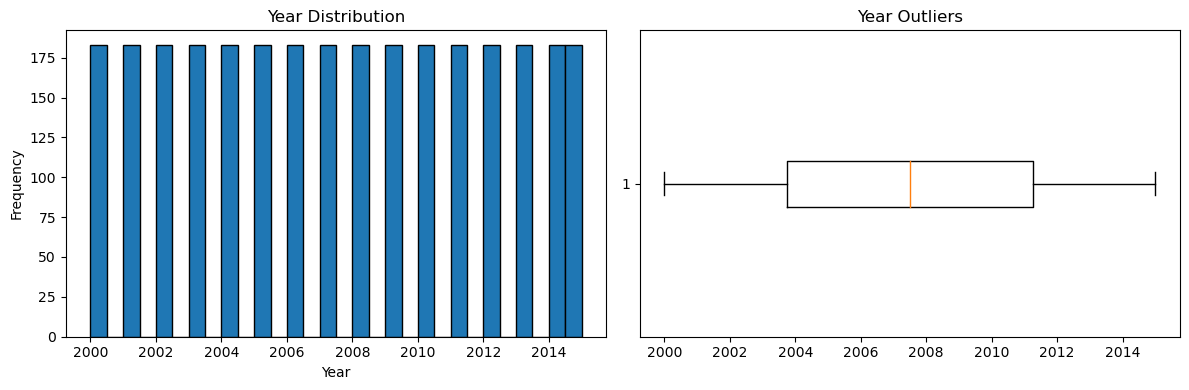

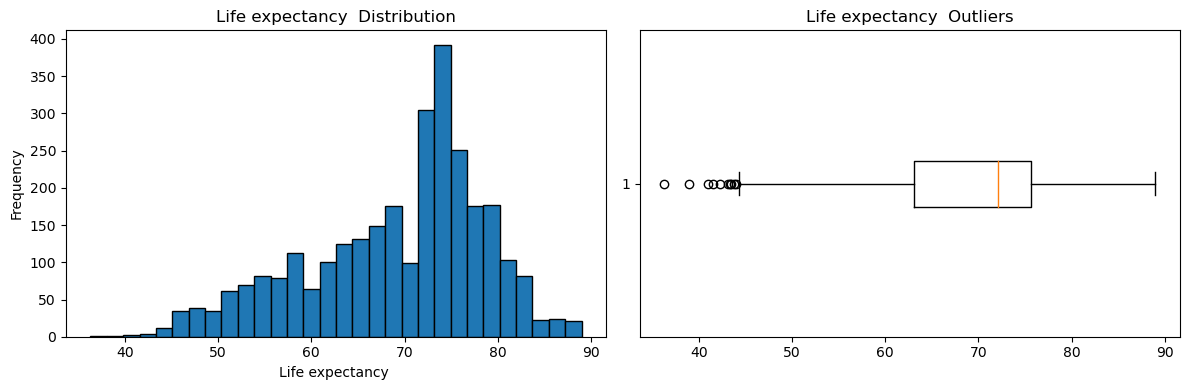

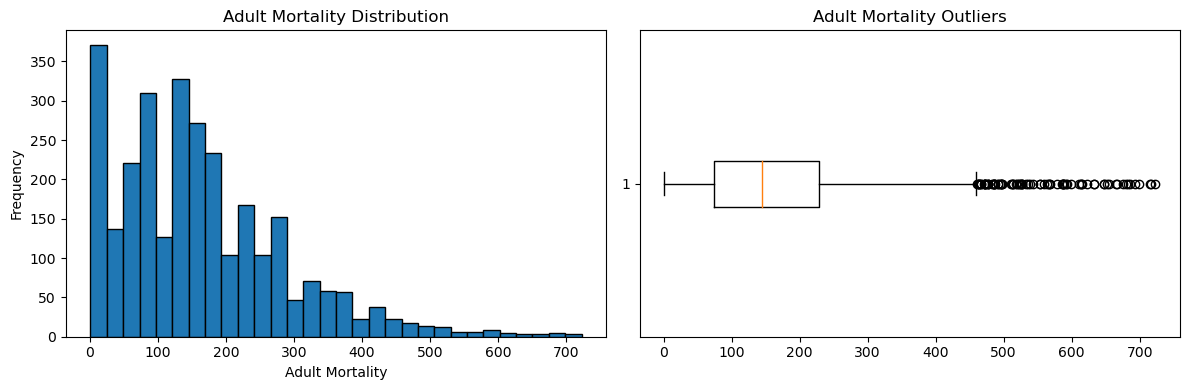

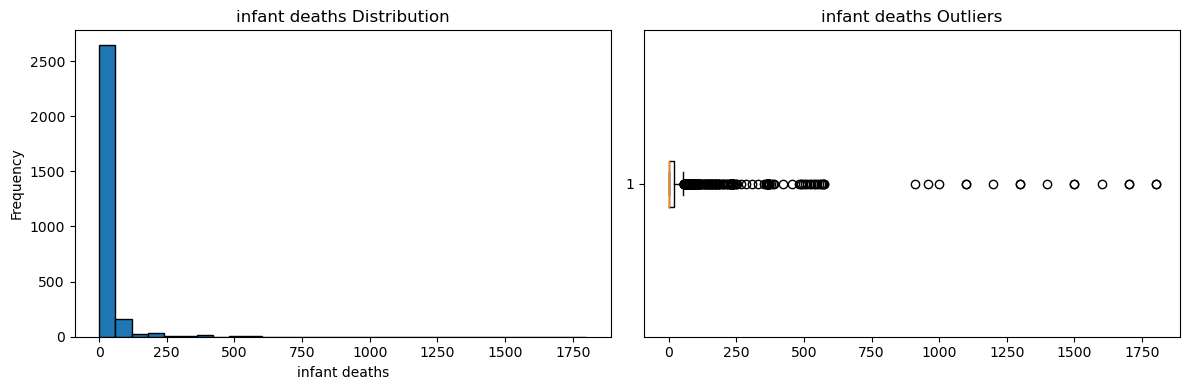

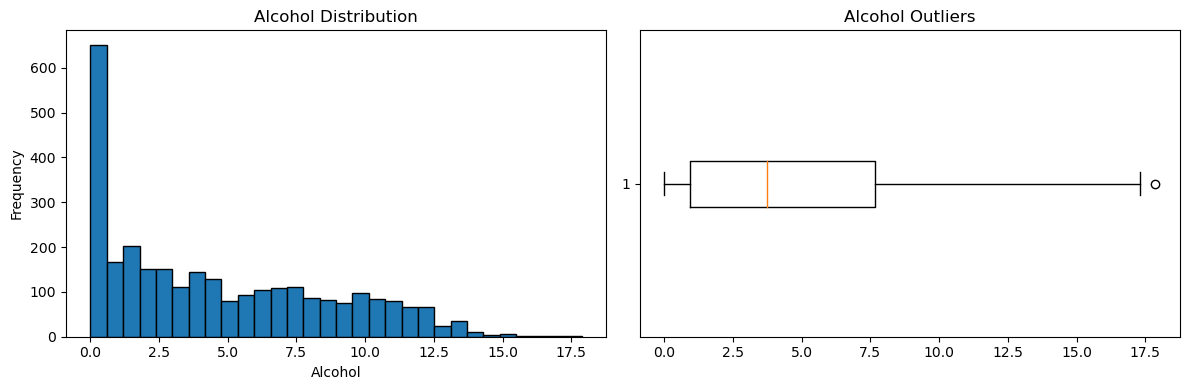

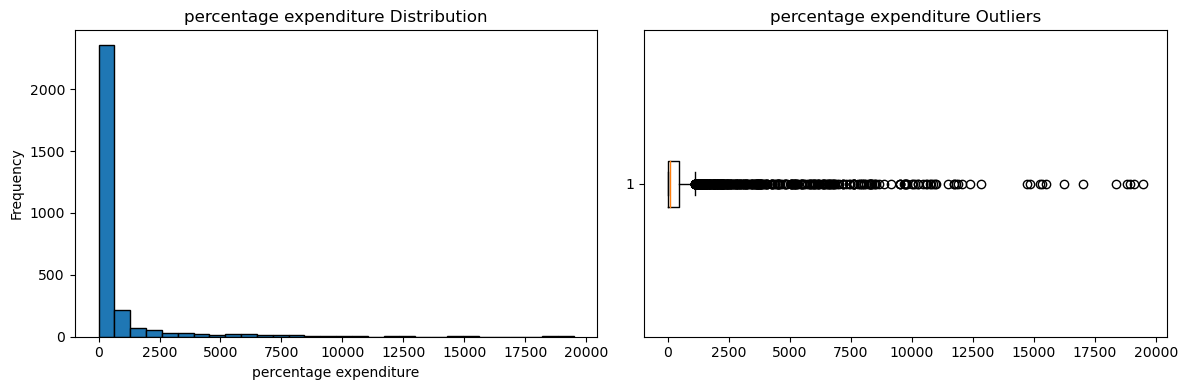

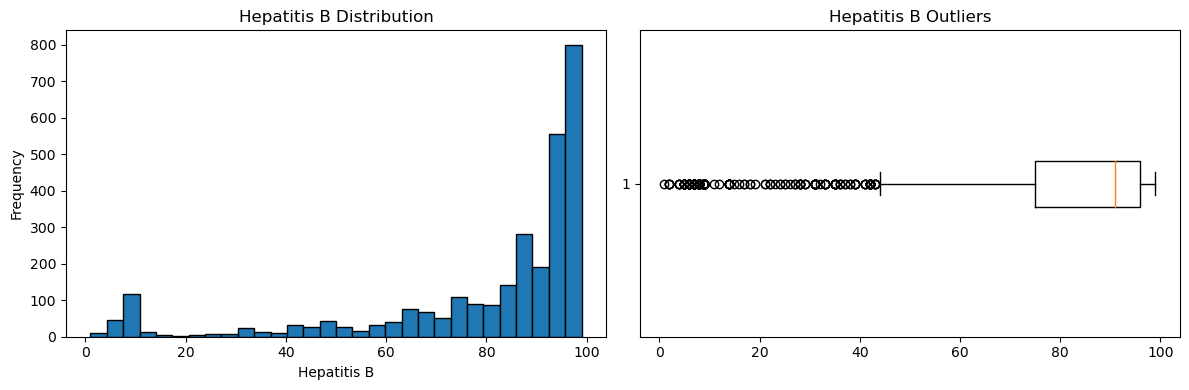

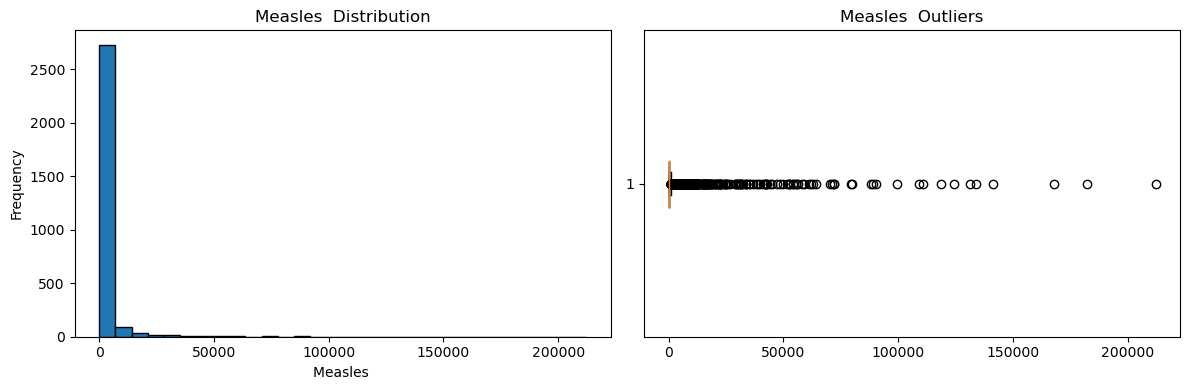

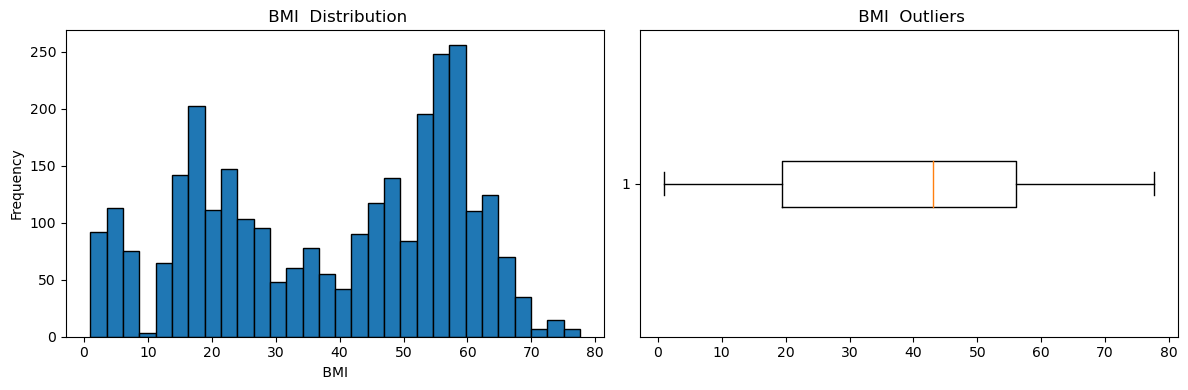

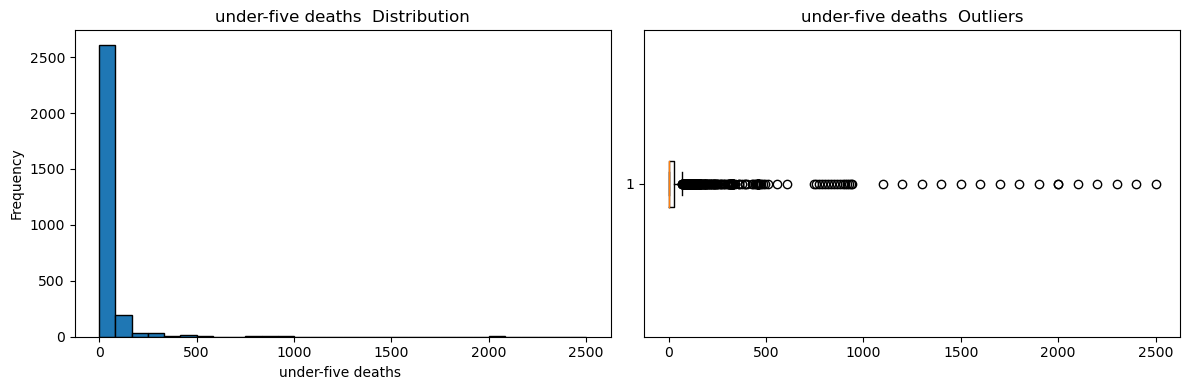

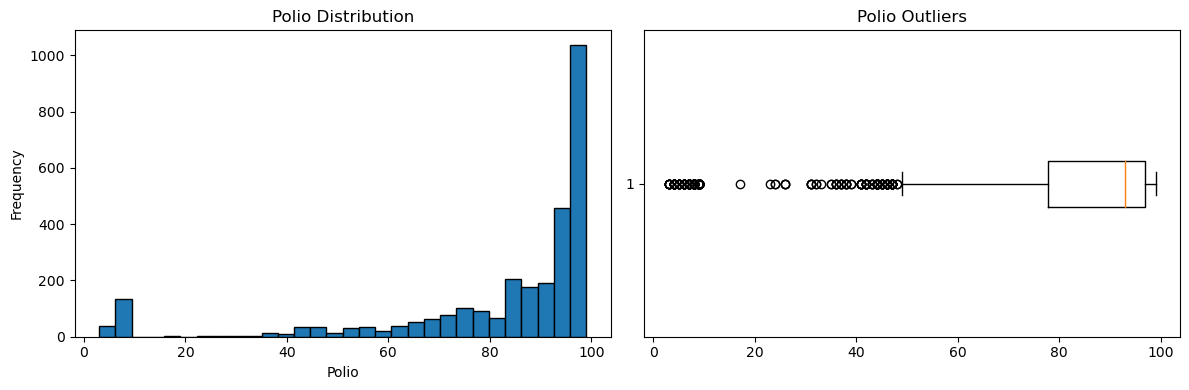

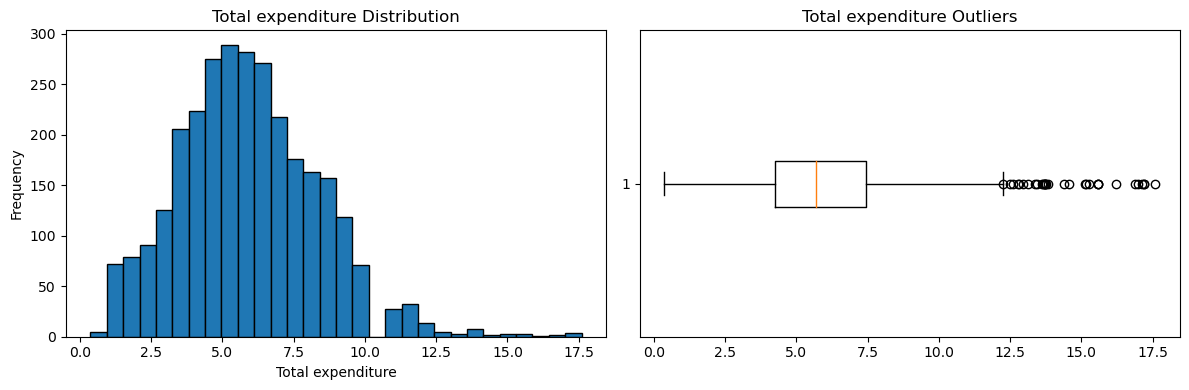

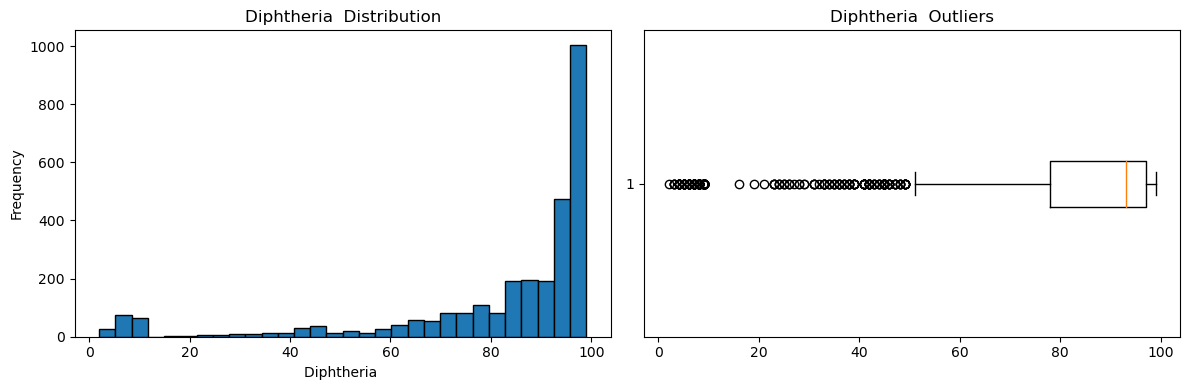

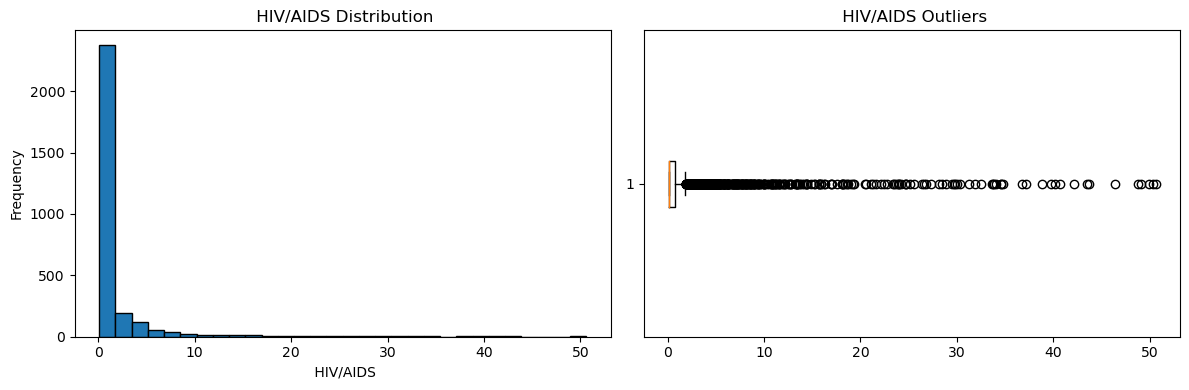

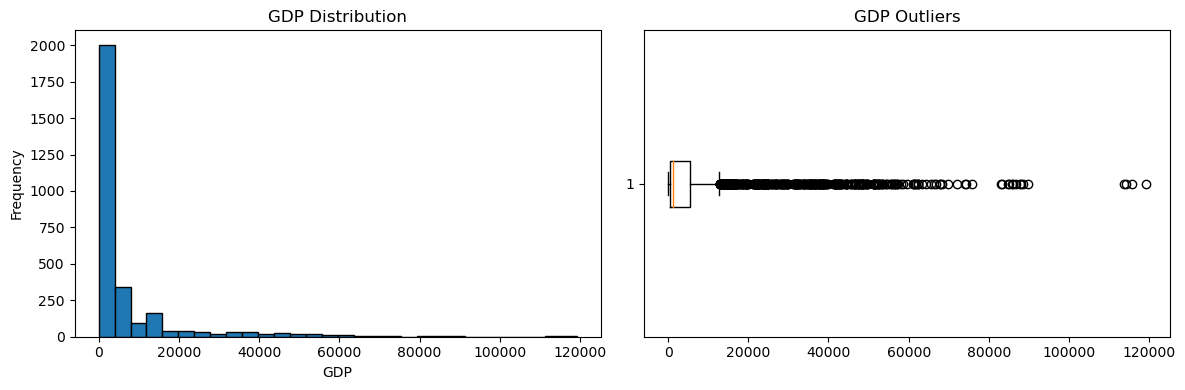

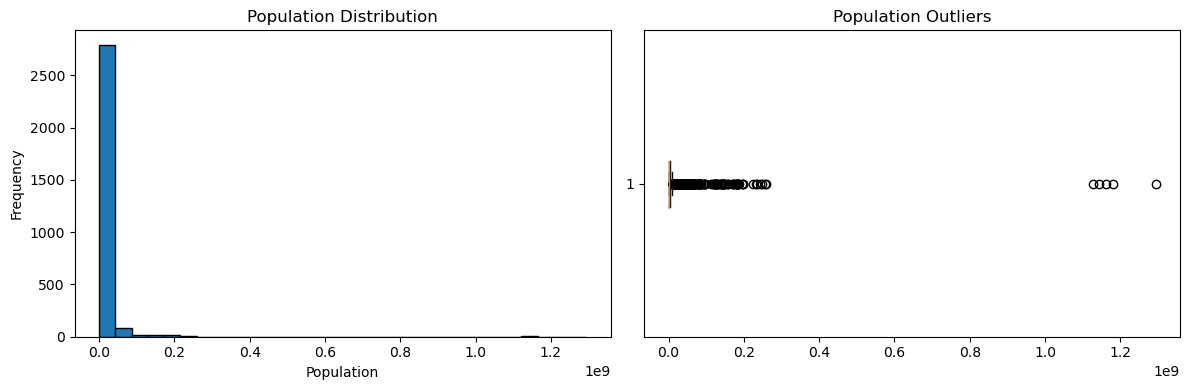

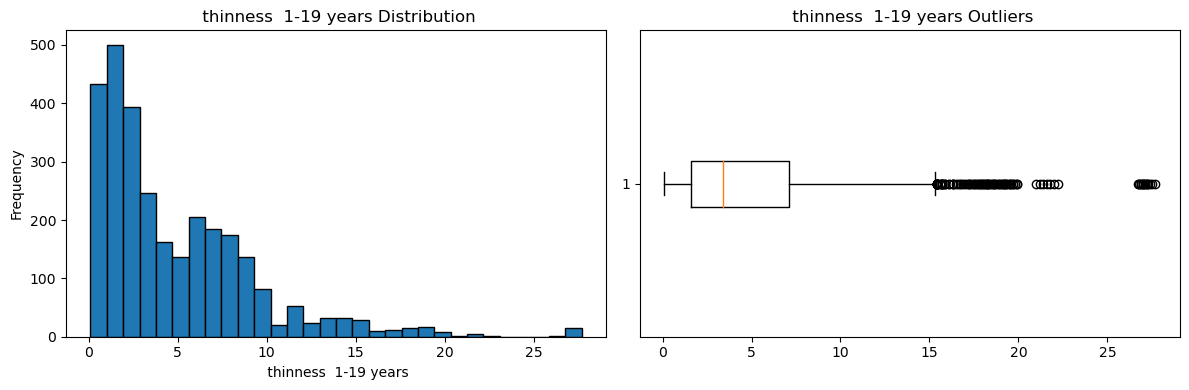

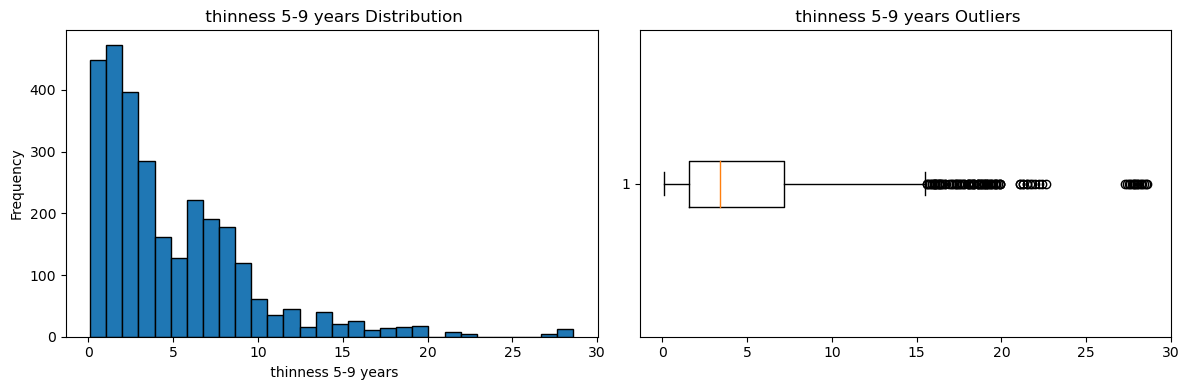

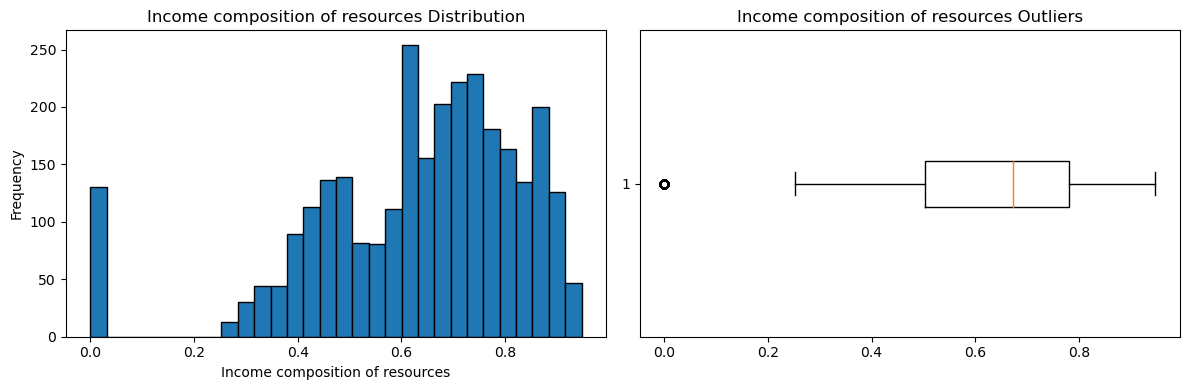

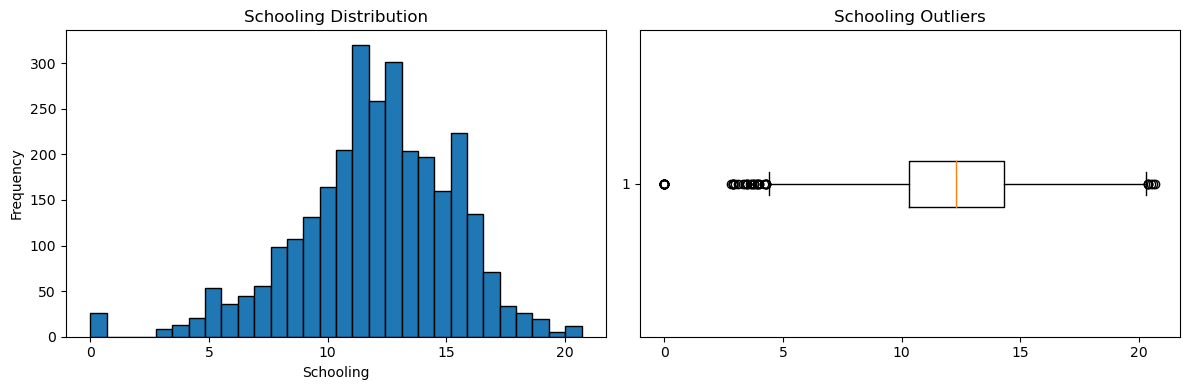

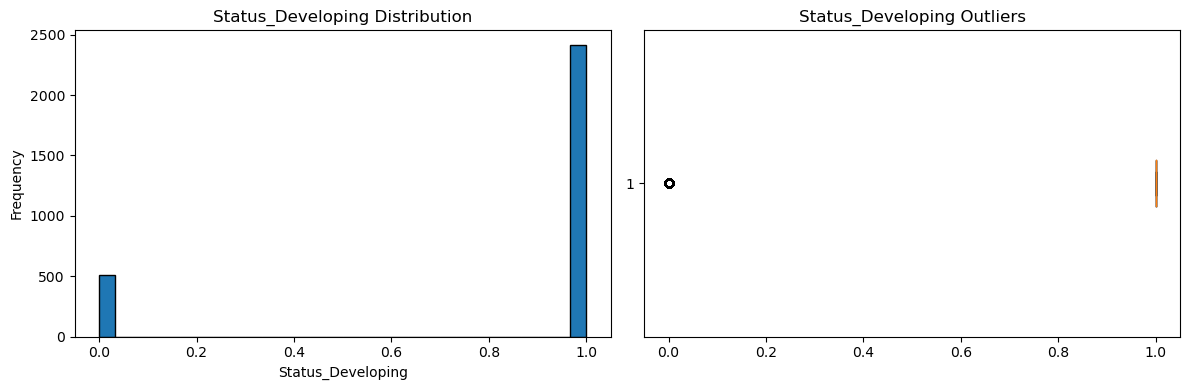

In [35]:
# check for extreeme values in the dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_cols = df.select_dtypes(include='number').columns

# Plot histogram and boxplot for each numerical column
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[0].set_title(f'{col} Distribution')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Boxplot
    axes[1].boxplot(df[col].dropna(), vert=False)
    axes[1].set_title(f'{col} Outliers')

    plt.tight_layout()
    plt.show()

In [36]:
# 1. Log-transform the legitimately skewed columns
#    (real-world extreme values, not data errors - see boxplot analysis)
#    np.log1p is used instead of np.log because it handles zero values safely (log1p(0) = 0)
skewed_cols = [
    'infant deaths', 'percentage expenditure', 'Measles ','under-five deaths ', ' HIV/AIDS', 'GDP', 'Population', 'Hepatitis B', 'Polio', 'Diphtheria ',
    ' thinness  1-19 years'
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [37]:
from sklearn.model_selection import train_test_split
# 2. Separate features (X) and target (y)
X = df.drop(columns=['Life expectancy ', 'Country'])
y = df['Life expectancy ']

# 3. Train-test split BEFORE scaling, to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
# Correlation analysis
# Merging x_train and y_train into a single DataFrame for correlation analysis
df_train = X_train.copy()
df_train['life_expectancy'] = y_train

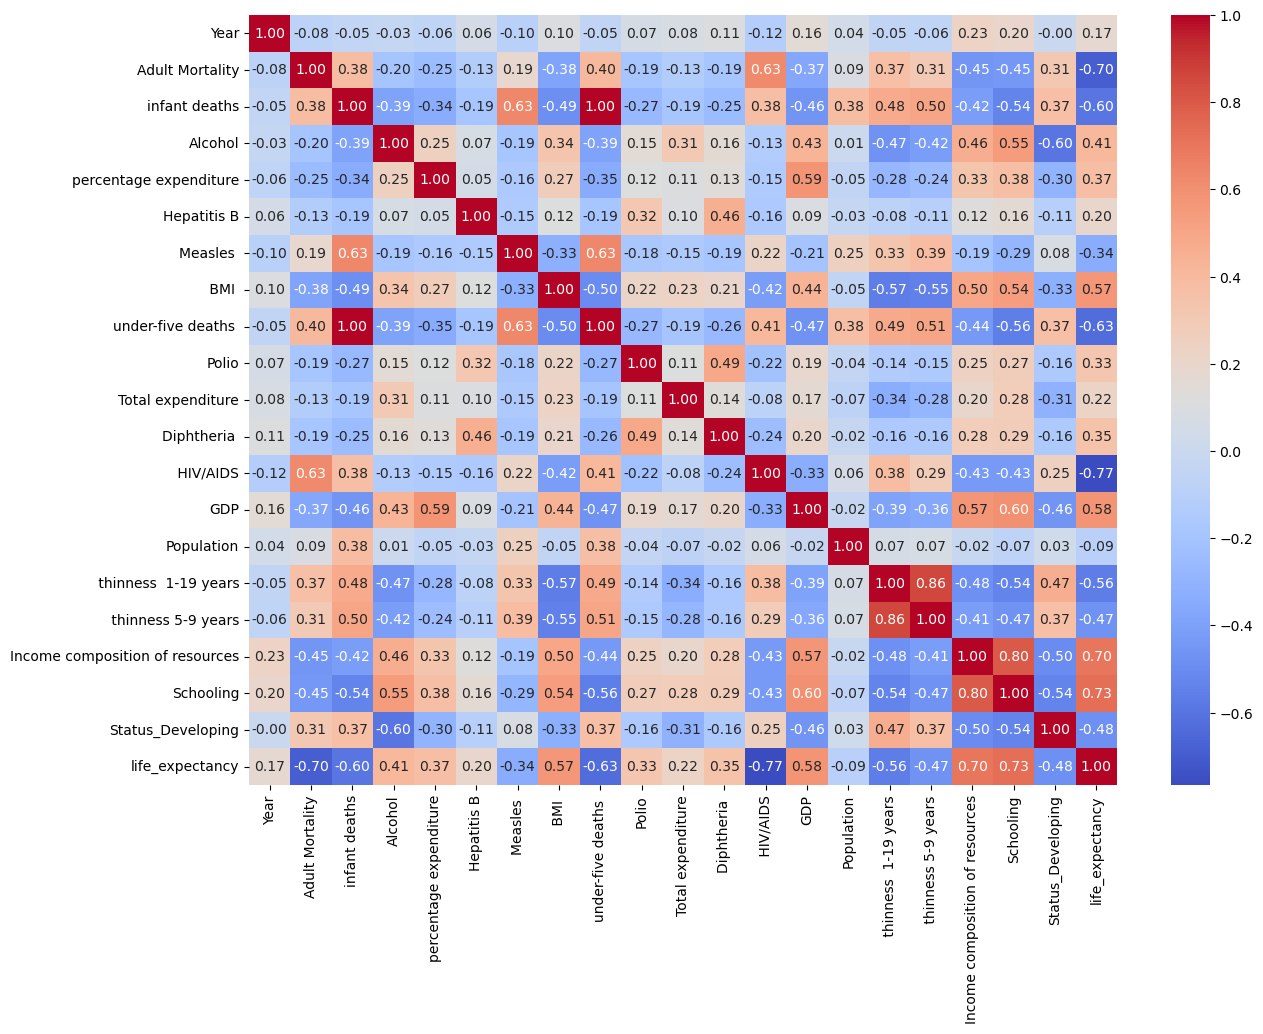

In [39]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize = (14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.show()

In [40]:
# Feature selection 
X_train = X_train.drop(columns=['Year', 'Total expenditure', 'Population', 'infant deaths', ' thinness 5-9 years'])
X_test = X_test.drop(columns=['Year', 'Total expenditure', 'Population', 'infant deaths', ' thinness 5-9 years'])

In [41]:
# Scaling the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [42]:
# Create and fit the model on the training data

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [43]:
# Predict on the test set

y_pred = model.predict(X_test_scaled)

In [44]:
# Evaluate the model's performance using R-squared and Mean Squared Error (MSE)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 score: 0.8493
RMSE: 3.6099
MAE: 2.7584
